In [1]:
!pip install pandas
!pip install numpy

In [2]:
import pandas as pd
import numpy as np

In [3]:
url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [4]:
df.copy()

In [5]:
print(df.dtypes)
print(df.shape)

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object
(5000, 19)


In [6]:
print(df.isnull().sum())

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df["posted_at"].dtype)

object


In [9]:
df["posted_at"] = pd.to_datetime(df["posted_at"] , errors="coerce")

/tmp/ipykernel_1820/455869668.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["posted_at"] = pd.to_datetime(df["posted_at"] , errors="coerce")


In [10]:
print(df["posted_at"].dtype)

datetime64[ns]


In [11]:
df["likes"] = pd.to_numeric(df["likes"], errors="coerce")
df["comments"] = pd.to_numeric(df["comments"], errors="coerce")
df["shares"] = pd.to_numeric(df["shares"], errors="coerce")

In [12]:
df["sentiment"].unique()

array(['negative', 'positive', 'neutral', nan], dtype=object)

In [13]:
df["sentiment"].value_counts()

,count
sentiment,
positive,2363
neutral,1527
negative,960


In [14]:
df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode()[0])

In [15]:
df["gender"].value_counts()

,count
gender,
Male,1699
Other,1581
Female,1570


In [16]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

In [17]:
df["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [18]:
df["gender"] = df["gender"].str.strip().str.title()

In [19]:
df["sentiment"] = df["sentiment"].str.strip().str.capitalize()

■ Correct unrealistic values in likes, comments, shares

In [20]:
print((df["likes"] < 0).sum())
print((df["comments"] < 0).sum())
print((df["shares"] < 0).sum())

0
0
0


In [21]:
df["likes"] = df["likes"].fillna(df["likes"].median())
df["comments"] = df["comments"].fillna(df["comments"].median())
df["shares"] = df["shares"].fillna(df["shares"].median())

In [22]:
df["user_id"]=df["user_id"].astype(str)
df["post_id"]=df["post_id"].astype(str)

In [23]:
df["Hashtag_Count"] = (df["hashtags"].fillna("").str.count("#"))

In [24]:
print(df[["hashtags", "Hashtag_Count"]].head())

                hashtags  Hashtag_Count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [25]:
df["age"] = df["age"].fillna(df["age"].median())

■ Clean sentiment labels


In [26]:
print(df["sentiment"].unique())

['Negative' 'Positive' 'Neutral']


In [27]:
df.sample(5)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,Hashtag_Count
1774,32431,28.0,Male,UAE,296582,text,fitness,12188.0,2989.0,790.0,5231,58175,2023-03-06,58979,False,mobile,Positive,#foodie,0.274465,1
3694,57591,62.0,Male,Australia,130365,video,travel,19001.0,1589.0,1553.0,3719,59976,2023-07-08,37221,True,tablet,Positive,#music #fitness #fun,0.369198,3
3100,17368,25.0,Female,India,703672,video,food,15670.0,1941.0,36.0,5416,20449,2023-03-13,651556,False,mobile,Negative,#fun #fashion #music,0.862976,3
44,18792,25.0,Male,Canada,307977,video,tech,8151.0,739.0,330.0,1663,74315,2022-01-05,117310,False,desktop,Positive,#foodie #music #love,0.124066,3
1159,34917,19.0,Male,Japan,790944,text,food,3978.0,1630.0,1443.0,1499,19603,2023-08-04,537891,False,tablet,Positive,#tech,0.359690,1


Task 3 – Data Exploration using Pandas

In [28]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,Hashtag_Count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.777372,1


In [29]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,Hashtag_Count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,Positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3


In [30]:
print(df.shape)

(5000, 20)


In [31]:
print(df.columns)

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'Hashtag_Count'],
      dtype='object')


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   object        
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   object        
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [33]:
print(df.dtypes)

user_id                     object
age                        float64
gender                      object
country                     object
post_id                     object
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
Hashtag_Count                int64
dtype: object


In [34]:
df.describe()

,age,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,Hashtag_Count
count,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,38.440400,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,13.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,26.000000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,38.000000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,51.000000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,64.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,14.687151,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [35]:
print(df["gender"].value_counts())

gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64


In [36]:
print(df["country"].value_counts())

country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64


In [37]:
print(df["post_type"].value_counts())

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64


In [38]:
print(df["sentiment"].value_counts())

sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64


In [39]:
print(df["country"].unique())

['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']


In [40]:
print(df["post_type"].unique())

['image' 'reel' 'text' 'video']


In [41]:
print(df["country"].nunique())

10


In [42]:
print(df["post_category"].nunique())

8


In [43]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()
print(corr_matrix)

                       age     likes  comments    shares  watch_time_sec  \
age               1.000000 -0.036322 -0.007284  0.013871        0.005542   
likes            -0.036322  1.000000 -0.018421  0.004712        0.008710   
comments         -0.007284 -0.018421  1.000000  0.006142       -0.016351   
shares            0.013871  0.004712  0.006142  1.000000        0.014658   
watch_time_sec    0.005542  0.008710 -0.016351  0.014658        1.000000   
impression_count  0.013322  0.007952 -0.009395 -0.005204       -0.004335   
follower_count   -0.024894 -0.022982 -0.011733 -0.010783        0.002761   
engagement_rate   0.008039  0.093520  0.000051  0.021724       -0.001148   
Hashtag_Count     0.007173 -0.002190 -0.015230  0.013379       -0.023301   

                  impression_count  follower_count  engagement_rate  \
age                       0.013322       -0.024894         0.008039   
likes                     0.007952       -0.022982         0.093520   
comments                 -

In [44]:
print(df.groupby("post_type")["likes"].mean())

post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64


In [45]:
print(df.groupby("country")["impression_count"].mean().round(2))

country
Australia    48346.38
Brazil       49193.17
Canada       48703.15
France       51727.67
Germany      48605.41
India        52462.39
Japan        49616.14
UAE          48928.41
UK           51119.39
USA          51263.87
Name: impression_count, dtype: float64


In [46]:
print(df.groupby("country")["impression_count"].sum())

country
Australia    23834767
Brazil       24793360
Canada       24984716
France       25656926
Germany      23816649
India        28067377
Japan        23418816
UAE          24610992
UK           25201861
USA          25683200
Name: impression_count, dtype: int64


In [47]:
print(df.groupby("country")["engagement_rate"].mean().round(2))

country
Australia    1.32
Brazil       1.54
Canada       0.92
France       1.15
Germany      0.76
India        0.66
Japan        0.77
UAE          1.11
UK           0.85
USA          0.58
Name: engagement_rate, dtype: float64


In [48]:
print(df.groupby("post_type")[["comments", "shares"]].mean().round(2))

           comments   shares
post_type                   
image       1525.24  1019.29
reel        1504.19   982.04
text        1499.11  1013.99
video       1479.16   996.83


❖ Task 4 — Data Wrangling  
● Use merge, concat, or join if combining DataFrames.

In [49]:
# for example
df1 = df[["user_id" , "country"]]

df2 = df[["user_id" , "likes"]]

merged_dfs = pd.merge(df1 , df2 , on="user_id")

merged_dfs.sample(7)

,user_id,country,likes
1999,59153,India,9016.0
5230,30527,India,15741.0
1788,29982,Canada,15588.0
2605,38270,UK,19098.0
4875,94811,India,9585.0
4372,95842,Brazil,10168.0
954,33275,Japan,2278.0


In [50]:
df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,Hashtag_Count,engagement_score
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1,16163.0
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1,6161.0
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.777372,1,16717.0


In [51]:
print(df.groupby("sentiment")[["likes", "comments", "shares"]].mean().round(2))

              likes  comments   shares
sentiment                             
Negative   10208.10   1516.09  1007.31
Neutral     9923.19   1528.40   996.57
Positive   10180.06   1480.65  1005.09


In [52]:
print(df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].mean().round())

likes               10107.0
comments             1502.0
shares               1003.0
watch_time_sec       4015.0
engagement_rate         1.0
follower_count     393698.0
dtype: float64


In [53]:
print(df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].median().round())

likes               10106.0
comments             1497.0
shares               1012.0
watch_time_sec       4034.0
engagement_rate         0.0
follower_count     388982.0
dtype: float64


In [54]:
print(df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].mode().iloc[0])

likes               10105.500000
comments             1497.000000
shares               1012.000000
watch_time_sec        916.000000
engagement_rate         0.006363
follower_count     497502.000000
Name: 0, dtype: float64


In [55]:
print(df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].std().round())

likes                5702.0
comments              856.0
shares                571.0
watch_time_sec       2308.0
engagement_rate         5.0
follower_count     230928.0
dtype: float64


In [56]:
print(df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].var().round(2))

likes              3.251615e+07
comments           7.334095e+05
shares             3.258757e+05
watch_time_sec     5.327309e+06
engagement_rate    2.828000e+01
follower_count     5.332769e+10
dtype: float64


In [57]:
percentiles = df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].quantile([0.25,0.50,0.75])

percentiles.index = ["25%","50%","75%"]

print(percentiles)

       likes  comments  shares  watch_time_sec  engagement_rate  \
25%   5235.0    792.00   511.0         2017.75         0.145781   
50%  10105.5   1497.00  1012.0         4034.50         0.253896   
75%  14959.0   2235.25  1483.0         6020.25         0.504794   

     follower_count  
25%       194480.00  
50%       388982.00  
75%       589744.25  


In [58]:
print(df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].skew().round(2))

likes              -0.01
comments            0.00
shares             -0.01
watch_time_sec     -0.02
engagement_rate    18.78
follower_count      0.04
dtype: float64


In [59]:
print(df[["likes","comments","shares","watch_time_sec","engagement_rate","follower_count"]].kurt().round(2))

likes               -1.15
comments            -1.14
shares              -1.15
watch_time_sec      -1.20
engagement_rate    482.99
follower_count      -1.19
dtype: float64


❖ Task 6 — Data Visualization

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

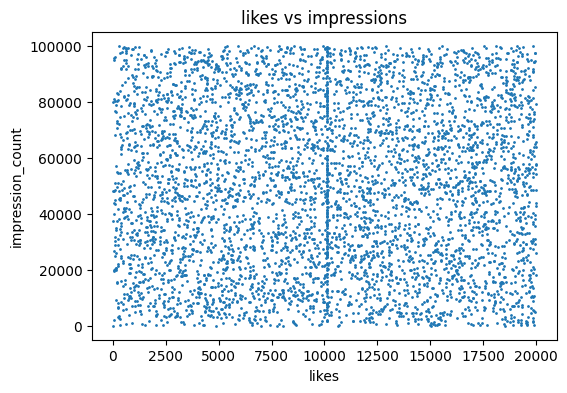

In [61]:
plt.figure(figsize=(6,4))
plt.scatter(df["likes"] , df["impression_count"] , s=1)
plt.title("likes vs impressions")
plt.xlabel("likes")
plt.ylabel("impression_count")
plt.show()

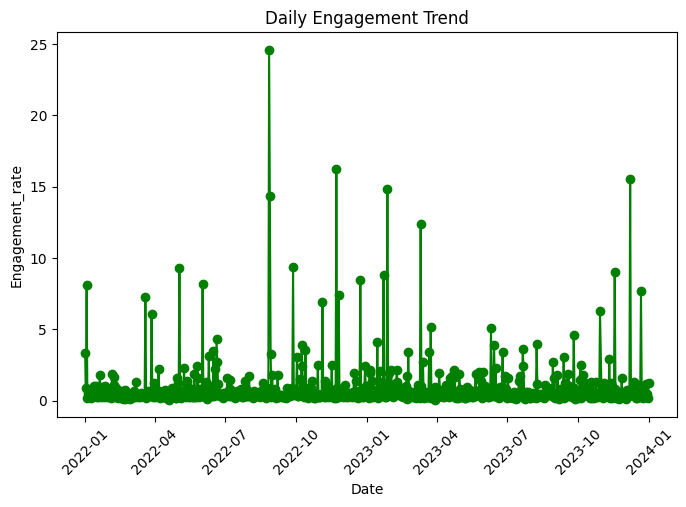

In [62]:
daily_engagement = df.groupby("posted_at")["engagement_rate"].mean()

plt.figure(figsize=(8,5))
plt.plot(daily_engagement , color ="green" , marker="o")
plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Engagement_rate")
plt.xticks(rotation=45)
plt.show()

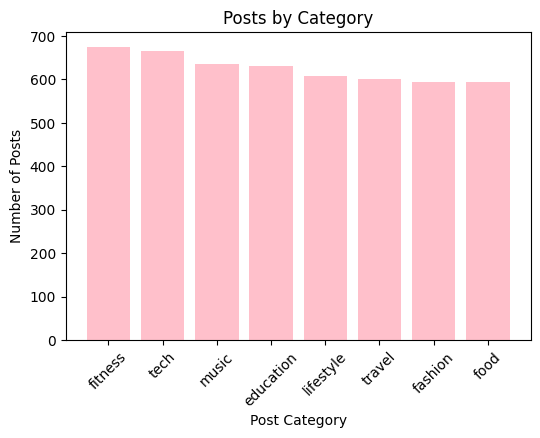

In [63]:
category_count = df["post_category"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(category_count.index, category_count.values, color="pink")
plt.title("Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

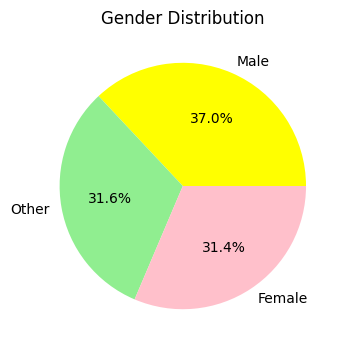

In [64]:
gender = df["gender"].value_counts()
plt.figure(figsize=(6,4))
plt.pie(gender , labels = gender.index , autopct="%1.1f%%" , colors=["yellow","lightgreen","pink"])
plt.title("Gender Distribution")
plt.show()

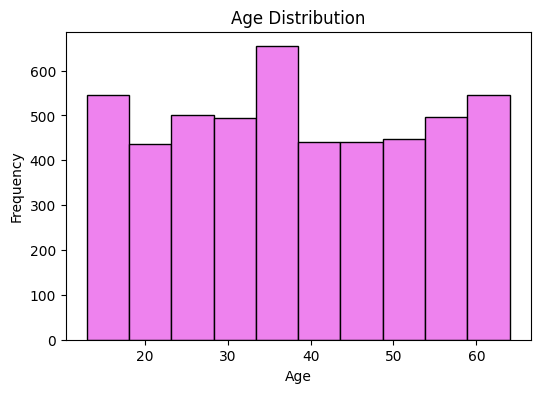

In [65]:
plt.figure(figsize=(6,4))
plt.hist(df["age"], bins=10 , color="violet" , edgecolor = "black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

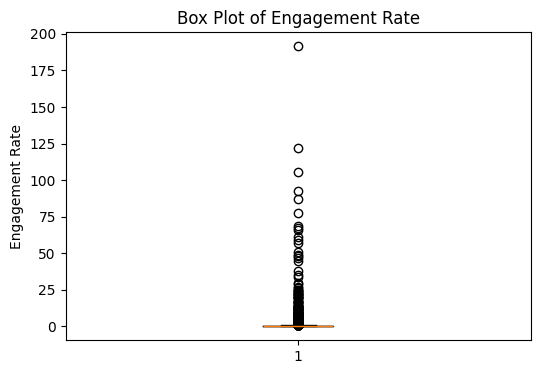

In [66]:
plt.figure(figsize=(6,4))
plt.boxplot(df["engagement_rate"])
plt.title("Box Plot of Engagement Rate")
plt.ylabel("Engagement Rate")
plt.show()

/tmp/ipykernel_1820/588621233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="post_type", data=df ,palette="pastel")


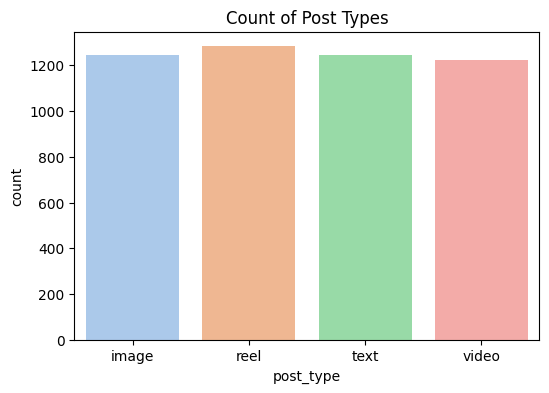

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x="post_type", data=df ,palette="pastel")
plt.title("Count of Post Types")
plt.show()

/tmp/ipykernel_1820/3389046169.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="post_category", y="likes", data=df , palette="pastel")


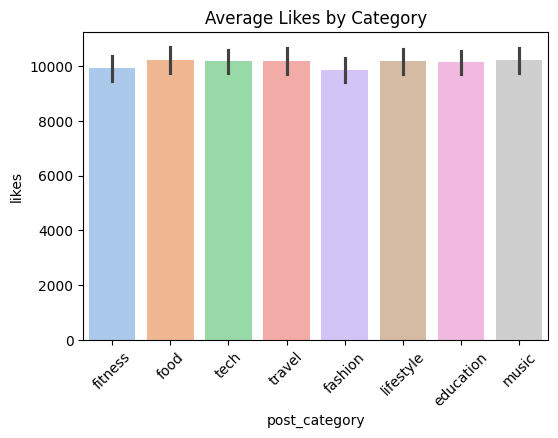

In [68]:
plt.figure(figsize=(6,4))
sns.barplot(x="post_category", y="likes", data=df , palette="pastel")
plt.title("Average Likes by Category")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1820/3468001610.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sentiment", y="follower_count", data=df , palette="Set3")


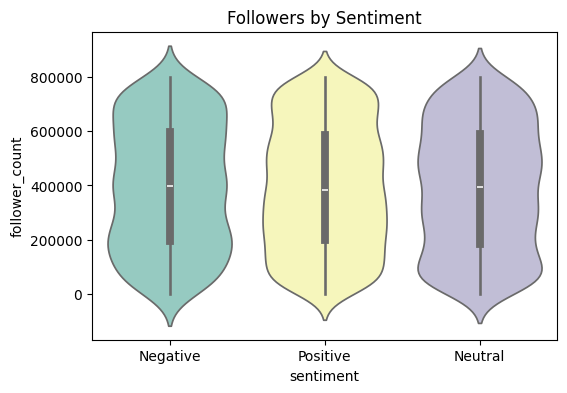

In [69]:
plt.figure(figsize=(6,4))
sns.violinplot(x="sentiment", y="follower_count", data=df , palette="Set3")
plt.title("Followers by Sentiment")
plt.show()

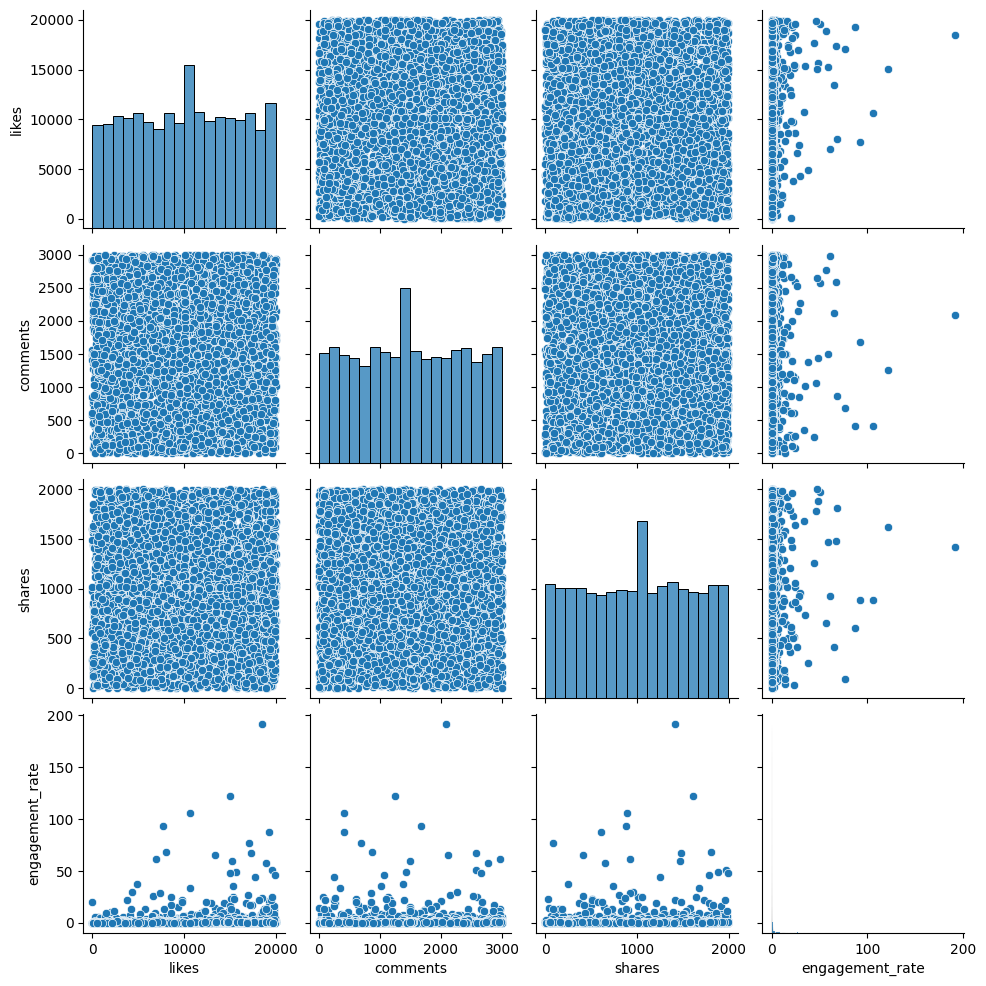

In [70]:
sns.pairplot(df[["likes","comments","shares","engagement_rate"]])
plt.show()

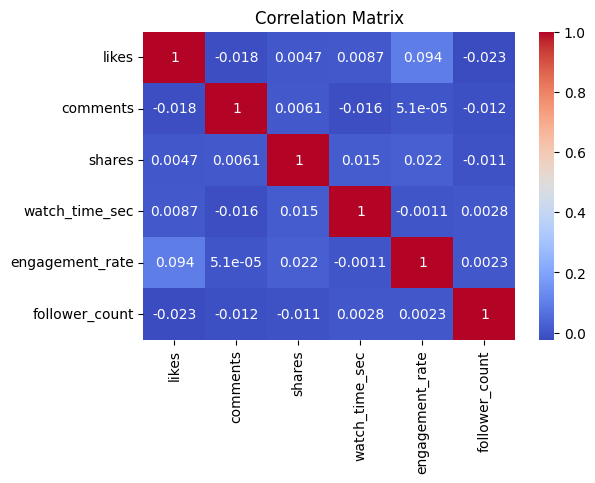

In [71]:
plt.figure(figsize=(6,4))
corr = df[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].corr()
sns.heatmap(corr, annot=True , cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [72]:
fig = px.line(df, x="posted_at", y="engagement_rate",
              title="Interactive Engagement Trend")
fig.show()

In [73]:
fig = px.bar(df,x="post_category",y="likes",title="Likes by Category")
fig.show()

In [74]:
fig = px.scatter(df,x="likes",y="impression_count",size="follower_count",color="post_type",title="Bubble Chart")
fig.show()

In [75]:
fig = px.scatter(df,x="likes",y="impression_count",color="post_type",title="Likes vs Impressions")
fig.show()